<a href="https://colab.research.google.com/github/MariiaOmelianenko/Calorie-Balance-and-Activity-Analysis/blob/main/Calorie_Balance_and_Activity_Analysi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Підключення до диску та створення датафреймів
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

path_nutrition = '/content/drive/MyDrive/Portfolio/nutrition.csv'
path_activity = '/content/drive/MyDrive/Portfolio/activity.csv'

df_nutrition = pd.read_csv(path_nutrition)
df_activity = pd.read_csv(path_activity)

df_nutrition.head()


Mounted at /content/drive


,Date,Meal,Calories,Carbs,Proteins,Fat,Calories AI,Carbs AI,Proteins AI,Fats AI
0,3/24/2026,Breakfast,421,14.8,20.0,23.2,300,12.5,20.0,20.0
1,3/24/2026,Lunch,385,27.1,38.7,18.0,550,60.0,35.0,25.0
2,3/24/2026,Dinner,368,40.3,17.5,18.1,450,63.0,17.0,23.0
3,3/24/2026,Snacks,170,3.0,17.0,10.0,200,12.5,16.5,10.0
4,3/25/2026,Breakfast,207,1.0,14.0,16.5,322,18.0,18.0,19.0


In [2]:
df_activity.head()

,Date,Steps,Steps_calories,Workout,Workout_type,Workout_calories
0,3/24/2026,9706,242.7,0,0,0
1,3/25/2026,6062,151.6,1,barre,188
2,3/26/2026,2687,67.2,0,0,0
3,3/27/2026,9369,234.2,1,barre,188
4,3/28/2026,15350,383.8,0,0,0


In [3]:
# Форматування назв колонок
df_nutrition.columns = df_nutrition.columns.str.lower().str.replace(' ', '_')
df_activity.columns = df_activity.columns.str.lower().str.replace(' ', '_')

In [4]:
# Приведення дати до необхідного формату
df_nutrition['date'] = pd.to_datetime(df_nutrition['date'])
df_activity['date'] = pd.to_datetime(df_activity['date'])
df_nutrition.info()
df_activity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         120 non-null    datetime64[ns]
 1   meal         120 non-null    object        
 2   calories     120 non-null    int64         
 3   carbs        120 non-null    float64       
 4   proteins     120 non-null    float64       
 5   fat          120 non-null    float64       
 6   calories_ai  120 non-null    int64         
 7   carbs_ai     120 non-null    float64       
 8   proteins_ai  120 non-null    float64       
 9   fats_ai      120 non-null    float64       
dtypes: datetime64[ns](1), float64(6), int64(2), object(1)
memory usage: 9.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date       

In [5]:
# Групування датасету з кбжу по даті
df_nutrition_daily = df_nutrition.groupby('date').agg({
    'calories': 'sum',
    'carbs': 'sum',
    'proteins': 'sum',
    'fat': 'sum',
    'calories_ai': 'sum',
    'carbs_ai': 'sum',
    'proteins_ai': 'sum',
    'fats_ai': 'sum'
}).reset_index()

In [6]:
df = df_nutrition_daily.merge(df_activity, on='date')

In [7]:
# Фінальна перевірка
df.shape
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              30 non-null     datetime64[ns]
 1   calories          30 non-null     int64         
 2   carbs             30 non-null     float64       
 3   proteins          30 non-null     float64       
 4   fat               30 non-null     float64       
 5   calories_ai       30 non-null     int64         
 6   carbs_ai          30 non-null     float64       
 7   proteins_ai       30 non-null     float64       
 8   fats_ai           30 non-null     float64       
 9   steps             30 non-null     int64         
 10  steps_calories    30 non-null     float64       
 11  workout           30 non-null     int64         
 12  workout_type      30 non-null     object        
 13  workout_calories  30 non-null     int64         
dtypes: datetime64[ns](1), float6

## Статистичні тести

In [16]:
# Кореляція між спожитими калоріями та активністю
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Калорії витрачені на ходьбу + тренування (за наявності)
df['calories_burned'] = df['steps_calories'] + df['workout_calories']

pearsonr(df['calories_burned'], df['calories'])

PearsonRResult(statistic=np.float64(0.4108240080817914), pvalue=np.float64(0.02412236661136339))

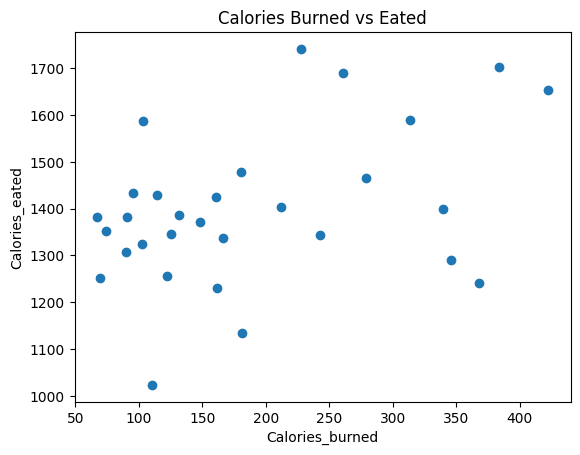

In [17]:
plt.scatter(df['calories_burned'], df['calories'])
plt.xlabel('Calories_burned')
plt.ylabel('Calories_eated')
plt.title('Calories Burned vs Eated')
plt.show()

Креляція між спожитими калоріями та активністю є статитсично значущою (p-value < 0.05), але звʼязок помірний 0.4. Це свідчить про те, що в дні з вищою активністю спостерігається тенденція до більшого споживання калорій


In [9]:
# Чи є різниця між цифрами отриманими від додатку та ШІ
# Беремо тест Вілкоксона, через те що працюємо з залежними вибірками

from scipy.stats import wilcoxon

wilcoxon(df['calories'], df['calories_ai'])


WilcoxonResult(statistic=np.float64(97.5), pvalue=np.float64(0.0054884676518012505))

P-value < 0.05, отже між вибірками є статистично значуща різниця. А отже це свідчить про те, що два інструменти оцінюють калорійність по-різному.

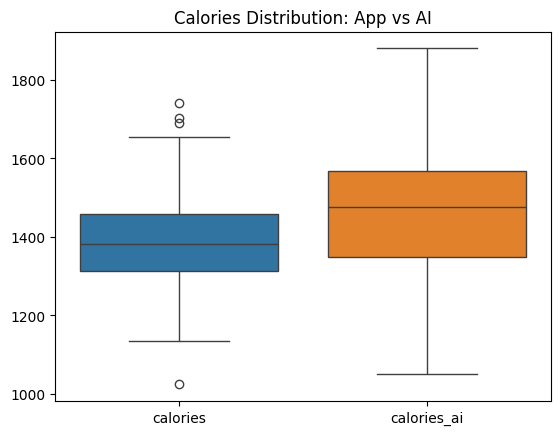

In [10]:
# Боксплот для оцінки кожного з інструментів
sns.boxplot(data=df[['calories', 'calories_ai']])
plt.title('Calories Distribution: App vs AI')
plt.show()

Медіана калорійності у ШІ вища, отже ШІ системно оцінює калорії вище, ніж додаток, також графік демонструє більший розкид длдя ШІ, отже він є менш стабільним. В той же час основні частини графіків перетинаються, отже значення що видають інструменти часто є близькими.

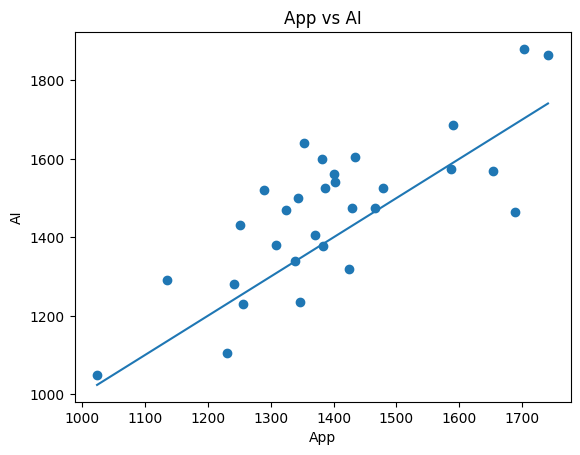

In [11]:
plt.scatter(df['calories'], df['calories_ai'])

plt.plot([df['calories'].min(), df['calories'].max()],
         [df['calories'].min(), df['calories'].max()],
         linestyle='-')

plt.xlabel('App')
plt.ylabel('AI')
plt.title('App vs AI')
plt.show()

В більшості випадків ШІ дає вищі значення

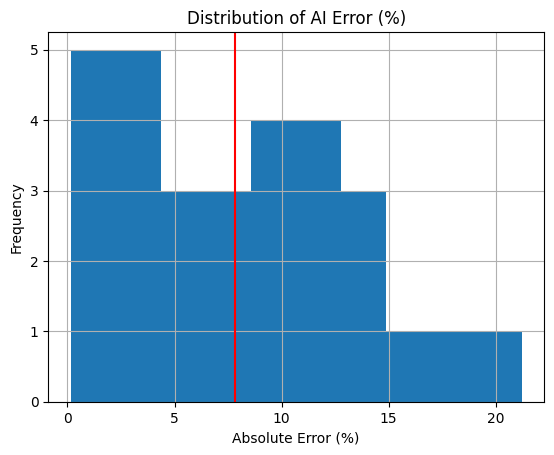

In [13]:
# Розрахунок абсолютної помилки ШІ плюс медіана
df['calories_diff'] = df['calories_ai'] - df['calories']
df['error_pct'] = df['calories_diff'] / df['calories']

df['abs_error_pct'] = df['error_pct'].abs() * 100
median = df['abs_error_pct'].median()

df['abs_error_pct'].hist(bins=10)

plt.axvline(median, linestyle='-', color='red')
plt.title('Distribution of AI Error (%)')
plt.xlabel('Absolute Error (%)')
plt.ylabel('Frequency')
plt.show()

Типова помилка AI становить приблизно 7–8% від калорійності раціону.

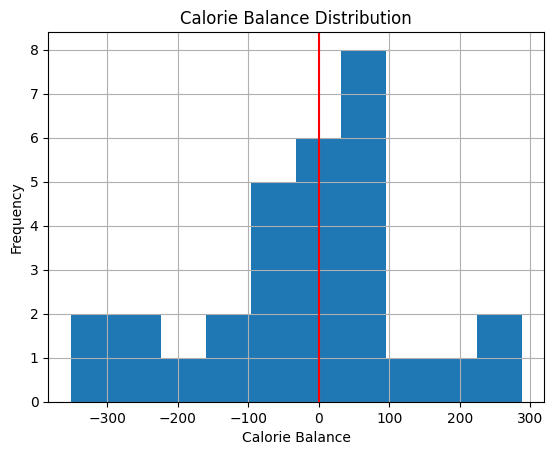

In [14]:
# Енергетичний баланс
df['base'] = 1225.5 # базові витрати (10⋅weight+6.25⋅height−5⋅age−161 = 1225.5)
df['total_burned'] = df['steps_calories'] + df['workout_calories'] + df['base']
df['calorie_balance'] = df['calories'] - df['total_burned']


df['calorie_balance'].hist(bins=10)

plt.axvline(0, linestyle='-', color = 'red')  # ключова лінія
plt.title('Calorie Balance Distribution')
plt.xlabel('Calorie Balance')
plt.ylabel('Frequency')

plt.show()

In [15]:
# Середній калорійний баланс та дні в дефіциті
mean_balance = df['calorie_balance'].mean()
deficit_days_pct = (df['calorie_balance'] < 0).mean() * 100

print(f"Average calorie balance: {mean_balance} kcal")
print(f"Days in deficit: {deficit_days_pct}%")

Average calorie balance: -16.403333333333354 kcal
Days in deficit: 53.333333333333336%


Незважаючи на те, що більше половини днів проходять у дефіциті, середній калорійний баланс близький до нуля, що свідчить про компенсацію дефіциту у профіцитні дні.

<Axes: xlabel='day_of_week'>

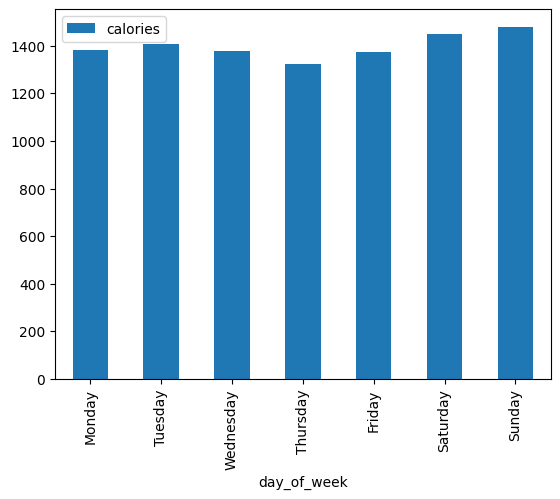

In [19]:
# Розподіл по днях тижня
df['day_of_week'] = df['date'].dt.day_name()
week_distribution = (df.groupby('day_of_week')['calories'].mean().reset_index())

order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

week_distribution['day_of_week'] = pd.Categorical(
    week_distribution['day_of_week'],
    categories=order,
    ordered=True)

week_distribution = week_distribution.sort_values('day_of_week')

week_distribution.plot(x='day_of_week', y='calories', kind='bar')

Споживання калорій зростає у вихідні (субота–неділя), що може пояснювати збільшення кількості днів із профіцитом у ці періоди